In [48]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data = pd.read_csv("Data/insurance.csv")
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [31]:
data["bmi_category"] = pd.cut(
    data["bmi"],
    bins = [0, 18.5, 25, 30, 100],
    labels = [0, 1, 2, 3]
)

In [32]:
data = data[data["charges"] < 50000]

In [33]:
data = pd.get_dummies(data, drop_first=True)

In [34]:
X = data.drop("charges", axis=1)
y = data["charges"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [37]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

In [38]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [39]:
model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [40]:
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation R²:", np.mean(cv_scores))

Cross-validation R²: 0.8510489025485558


In [41]:
test_score = model.score(X_test, y_test)
print("Test R² Score:", test_score)

Test R² Score: 0.8748147270624324


In [42]:
y_pred = model.predict(X_test)

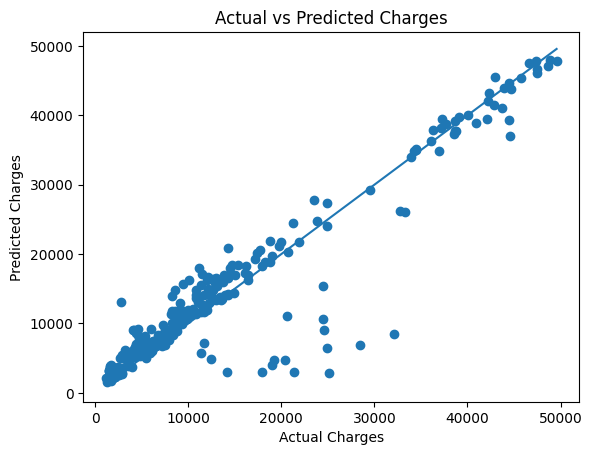

In [43]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

In [44]:
importances = model.feature_importances_
features = X.columns


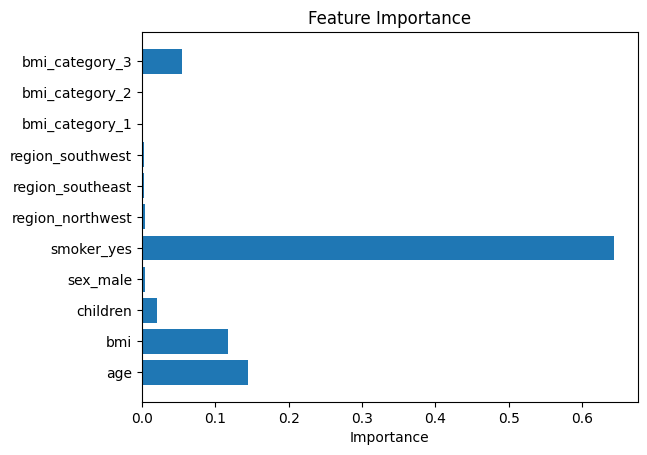

In [45]:
plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=data)
plt.title("BMI vs Charges")
plt.show()

NameError: name 'df' is not defined